## SECTION 1: Setup

### Imports

In [34]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sys
!{sys.executable} -m pip install kaleido==0.2.1


### Chart Style Settings

In [35]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

### Output Folder

In [36]:
FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

### Database Connection

In [37]:
import os
DB_PATH = Path("../data/processed/bluestock_mf.db")
conn = sqlite3.connect(str(DB_PATH))

### Load Tables

In [38]:
import pandas as pd

def q(query):
    return pd.read_sql(query, conn)

In [39]:
dim_fund = q("SELECT * FROM dim_fund")
fact_nav = q("SELECT * FROM fact_nav")
fact_transactions = q("SELECT * FROM fact_transactions")
fact_performance = q("SELECT * FROM fact_performance")
fact_aum = q("SELECT * FROM fact_aum")

### Fix Date Columns

In [40]:
fact_nav["date"] = pd.to_datetime(fact_nav["date"])
fact_transactions["transaction_date"] = pd.to_datetime(fact_transactions["transaction_date"])
fact_aum["date"] = pd.to_datetime(fact_aum["date"])
dim_fund["launch_date"] = pd.to_datetime(dim_fund["launch_date"])

### Load the Two Extra Raw Files We Need

In [41]:
sip_industry = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
sip_industry["month"] = pd.to_datetime(sip_industry["month"], format="%Y-%m")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
folio["month"] = pd.to_datetime(folio["month"], format="%Y-%m")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
holdings["amfi_code"] = holdings["amfi_code"].astype(str)

### Data Quality Notes (checked during EDA, not fixed — documented as known limitations)

- **dim_date table is empty.** It exists in the schema but was never populated in Day 2. 
  All date filtering/grouping in this notebook uses the date columns already present in 
  the fact tables directly, which works fine.
- **fact_aum has irregular reporting dates**, not a clean quarterly series (9 dates between 
  2022–2025, semi-annual in early years, more frequent later). Verified this matches the 
  raw source file exactly — not a loading bug, just how the source data is structured.

## SECTION 2: Chart 1 — NAV Trend (40 Schemes)

### Pick Anchor Funds to Show by Default

In [42]:
representative_codes = {
    "119120": "SBI Magnum Gilt (Debt-Gilt)",
    "120507": "ICICI Pru Liquid (Debt-Liquid)",
    "125497": "HDFC Top 100 Direct (Large Cap)",
    "125498": "HDFC Mid-Cap Direct (Mid Cap)",
    "119599": "SBI Small Cap Direct (Small Cap)",
    "102885": "UTI Nifty 50 Index (Index)",
}

### Prepare the Data

In [43]:
nav_all = fact_nav.merge(
    dim_fund[["amfi_code", "scheme_name"]],
    on="amfi_code", how="left"
)
nav_all = nav_all.sort_values(["amfi_code", "date"])

### Build the Chart

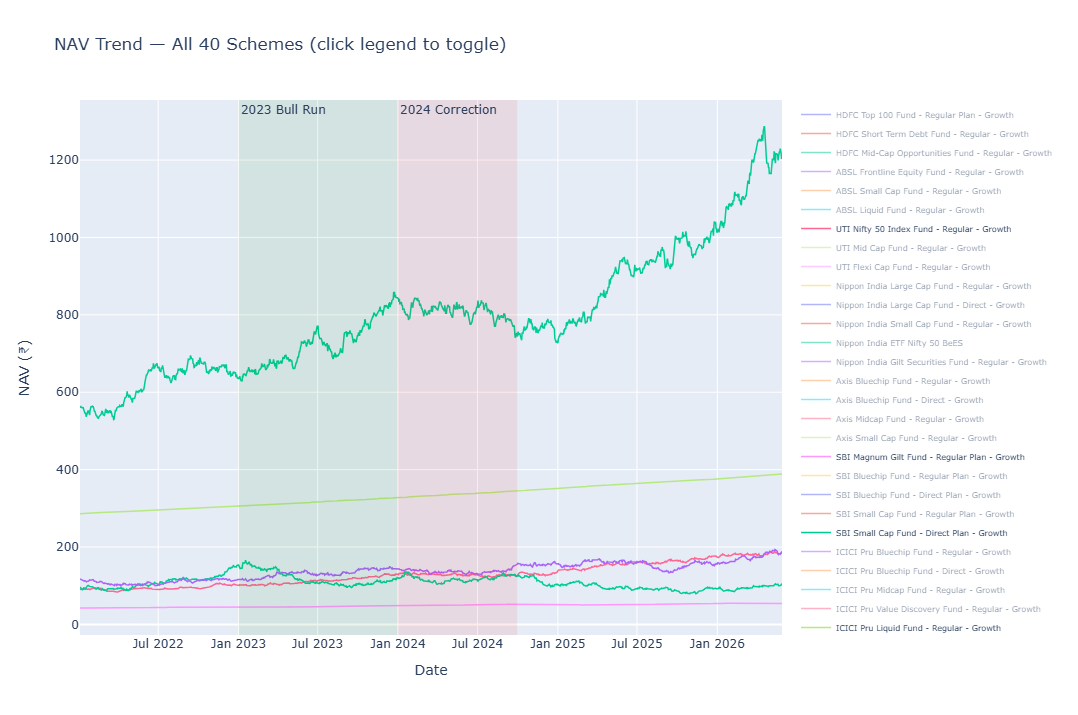

In [44]:
fig = go.Figure()

for code, group in nav_all.groupby("amfi_code"):
    fund_name = group["scheme_name"].iloc[0]
    show_by_default = code in representative_codes
    fig.add_trace(go.Scatter(
        x=group["date"],
        y=group["nav"],
        mode="lines",
        name=fund_name,
        visible=True if show_by_default else "legendonly",
        line=dict(width=1.5)
    ))

fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.08,
    annotation_text="2023 Bull Run", annotation_position="top left",
    line_width=0
)
fig.add_vrect(
    x0="2024-01-01", x1="2024-09-30",
    fillcolor="red", opacity=0.08,
    annotation_text="2024 Correction", annotation_position="top left",
    line_width=0
)

fig.update_layout(
    title="NAV Trend — All 40 Schemes (click legend to toggle)",
    xaxis_title="Date",
    yaxis_title="NAV (₹)",
    height=700,
    legend=dict(font=dict(size=8))
)
#fig.write_image(str(FIG_DIR / "01_nav_trend.png"), width=1400, height=800, scale=2)
fig.show()


### Finding: The Index Fund Shows a Genuine Bull Run and Correction

The UTI Nifty 50 Index fund — the closest proxy for "the market" — shows a genuine 
sustained bull run through 2023 (all four quarters positive, peaking at +9.9%) followed 
by a real correction in the first three quarters of 2024, before recovering sharply in 
Q4 2024. This is a notable exception to the otherwise independent, random-walk NAV 
patterns found elsewhere (Finding 1).

## SECTION 3: Chart 2 — AUM by Fund House, Grouped by Year

### Add a Year Column

In [45]:
fact_aum["year"] = fact_aum["date"].dt.year

### Get Each Fund House's Peak AUM Per Year

In [46]:
aum_by_year = fact_aum.groupby(["year", "fund_house"])["aum_crore"].max()
aum_by_year = aum_by_year.reset_index()

### Build the Chart

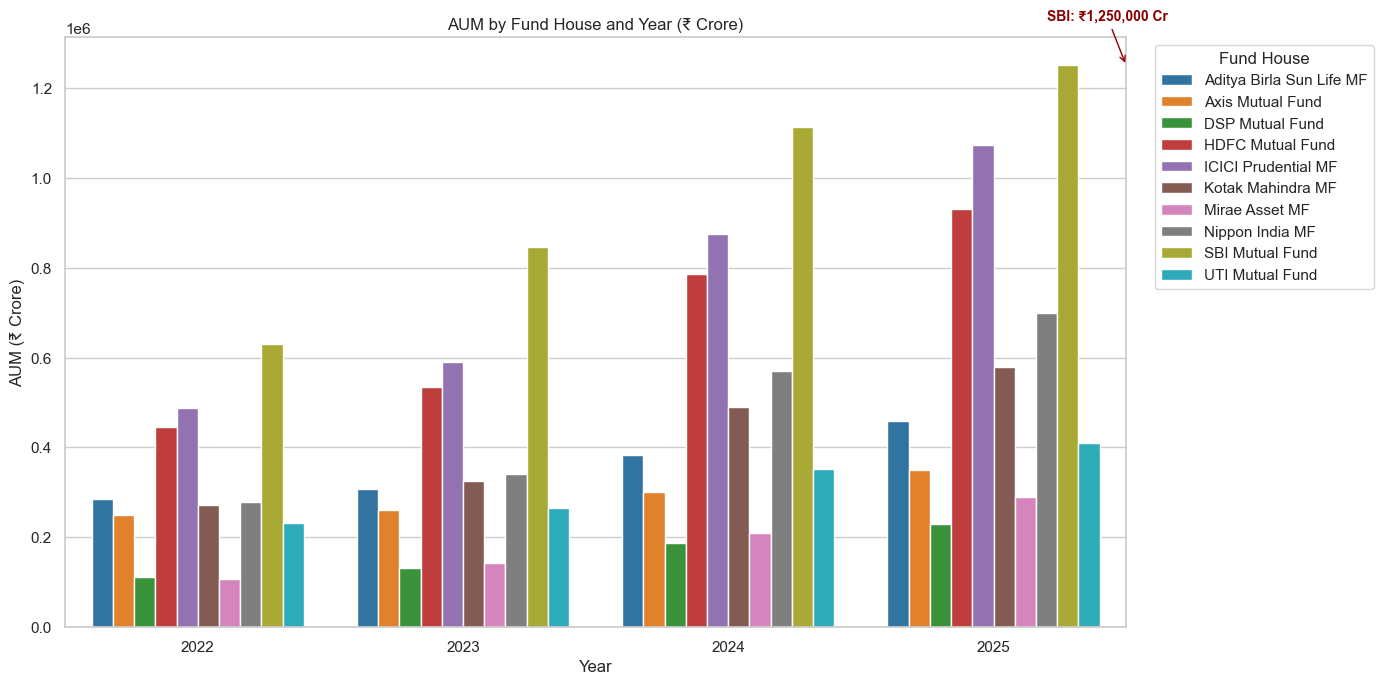

In [47]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_by_year,
    x="year", y="aum_crore", hue="fund_house",
    palette="tab10"
)

plt.title("AUM by Fund House and Year (₹ Crore)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left")

sbi_2025 = aum_by_year[
    (aum_by_year["fund_house"] == "SBI Mutual Fund") &
    (aum_by_year["year"] == 2025)
]
sbi_peak = sbi_2025["aum_crore"].values[0]

plt.annotate(
    f"SBI: ₹{sbi_peak:,} Cr",
    xy=(3.5, sbi_peak),
    xytext=(3.2, sbi_peak + 100000),
    fontsize=10, fontweight="bold", color="darkred",
    arrowprops=dict(arrowstyle="->", color="darkred")
)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_aum_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding: SBI Leads AUM Every Year, Widening Its Lead

SBI Mutual Fund leads AUM every year from 2022–2025, growing from ~₹630,000 Cr to 
₹1,250,000 Cr — nearly doubling and extending its lead over the field. All fund houses 
show steady growth, indicating broad industry expansion alongside SBI's specific dominance.

## SECTION 4: Chart 3 — SIP Inflow (Industry-Wide)

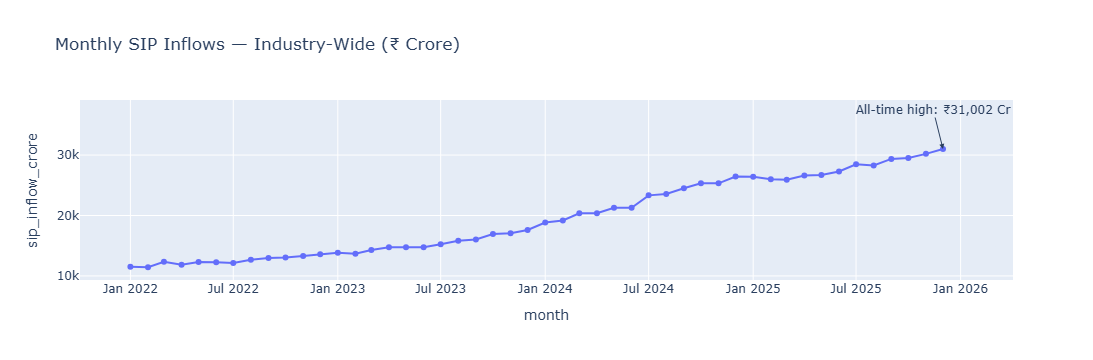

In [48]:
fig = px.line(
    sip_industry,
    x="month", y="sip_inflow_crore",
    title="Monthly SIP Inflows — Industry-Wide (₹ Crore)",
    markers=True,
    render_mode="svg"
)

peak_row = sip_industry.loc[sip_industry["sip_inflow_crore"].idxmax()]
peak_month_str = peak_row["month"].strftime("%Y-%m-%d")

fig.add_annotation(
    x=peak_month_str,
    y=peak_row["sip_inflow_crore"],
    text=f"All-time high: ₹{peak_row['sip_inflow_crore']:,} Cr",
    showarrow=True, arrowhead=2, ay=-40
)

fig.show()
#fig.write_image(str(FIG_DIR / "03_sip_inflow.png"), width=1200, height=700, scale=2)

In [49]:
import kaleido
print(kaleido.__version__)

0.2.1


### Finding: Industry SIP Inflows Grew ~2.7x, Peaking at ₹31,002 Cr

Industry-wide monthly SIP inflows grew steadily from ~₹11,500 Cr (Jan 2022) to an 
all-time high of ₹31,002 Cr (Dec 2025) — a ~2.7x increase with consistent upward 
momentum. This contrasts with the flatter, noisier pattern in the investor-level 
transaction sample, suggesting the sample represents a small subset rather than the 
full industry trend.

## SECTION 5: Chart 4 — Category Inflow Heatmap


### Attach Category to Each Transaction

In [50]:
txn_with_category = fact_transactions.merge(
    dim_fund[["amfi_code", "category"]],
    on="amfi_code", how="left"
)

### Sum SIP Inflow by Month and Category

In [51]:
sip_only = txn_with_category[txn_with_category["transaction_type"] == "SIP"].copy()
sip_only["month"] = sip_only["transaction_date"].dt.to_period("M").dt.to_timestamp()

category_monthly = sip_only.groupby(["month", "category"])["amount_inr"].sum()
category_monthly = category_monthly.reset_index()

### Reshape and Plot

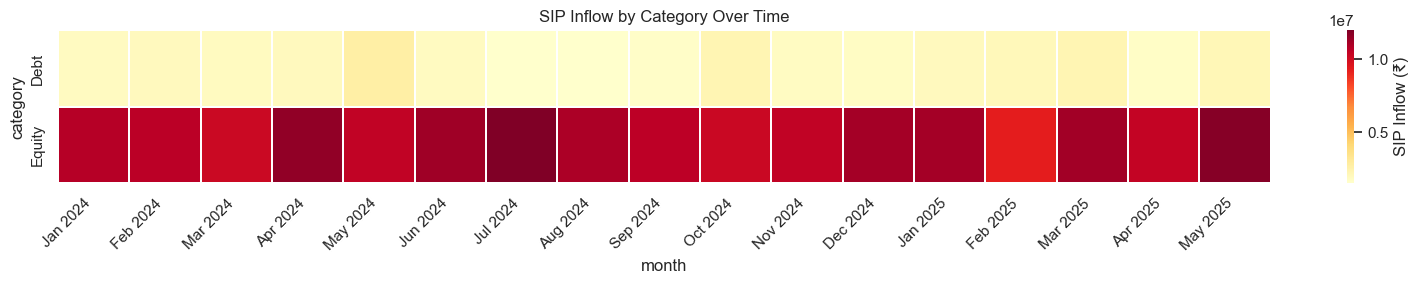

In [52]:
heatmap_data = category_monthly.pivot(index="category", columns="month", values="amount_inr")
heatmap_data.columns = heatmap_data.columns.strftime("%b %Y")

plt.figure(figsize=(16, 3))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "SIP Inflow (₹)"})
plt.title("SIP Inflow by Category Over Time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding: Equity Dominates SIP Inflow Every Month

SIP inflows are consistently dominated by Equity over Debt across every month studied, 
with no shift in this balance over time — consistent with the fund lineup itself 
(32 of 40 funds are Equity vs. 8 Debt).

## SECTION 6: Chart 5 — Investor Demographics

### Get One Row Per Investor

In [53]:
unique_investors = fact_transactions.drop_duplicates(subset=["investor_id"])
age_counts = unique_investors["age_group"].value_counts().sort_index()
gender_counts = unique_investors["gender"].value_counts()

### Plot Both

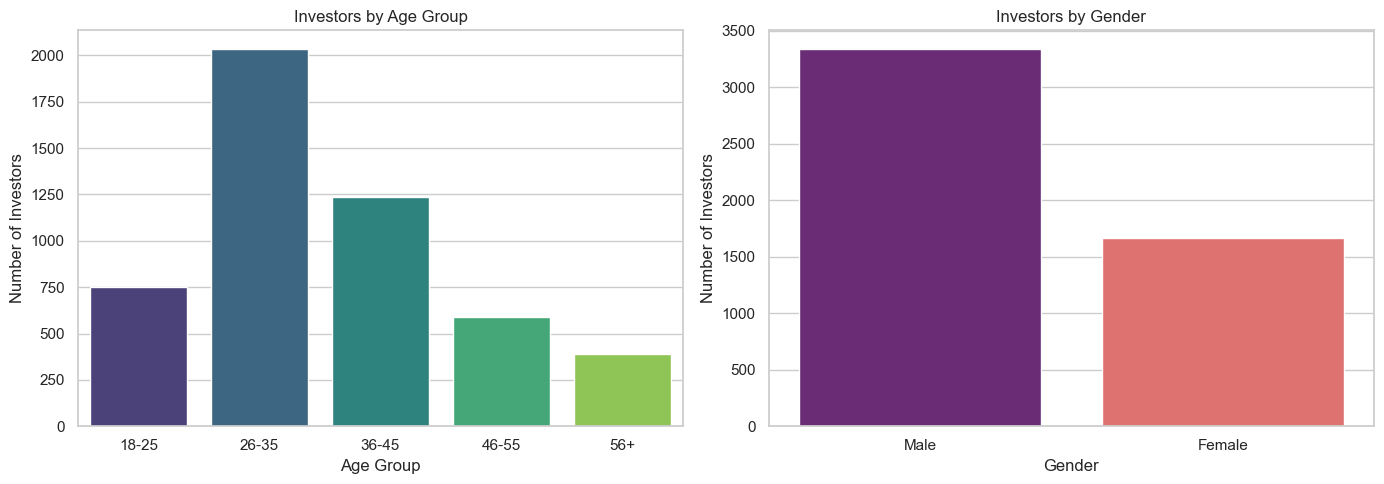

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=age_counts.index, y=age_counts.values, hue=age_counts.index,
            ax=axes[0], palette="viridis", legend=False)
axes[0].set_title("Investors by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Investors")

sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index,
            ax=axes[1], palette="magma", legend=False)
axes[1].set_title("Investors by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Investors")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding: Investor Base Skews Young and Male

The investor base skews toward the 26-35 age group (~2.7x the next largest bracket) 
and is male-dominated (~2:1) — both patterns consistent with known real-world retail 
mutual fund investor demographics in India.

## SECTION 7: Chart 6 — Geographic Distribution

### Get Location Per Unique Investor

In [55]:
geo = unique_investors[["state", "city_tier"]]
state_counts = geo["state"].value_counts().sort_values(ascending=False)
tier_counts = geo["city_tier"].value_counts()

### Plot Both

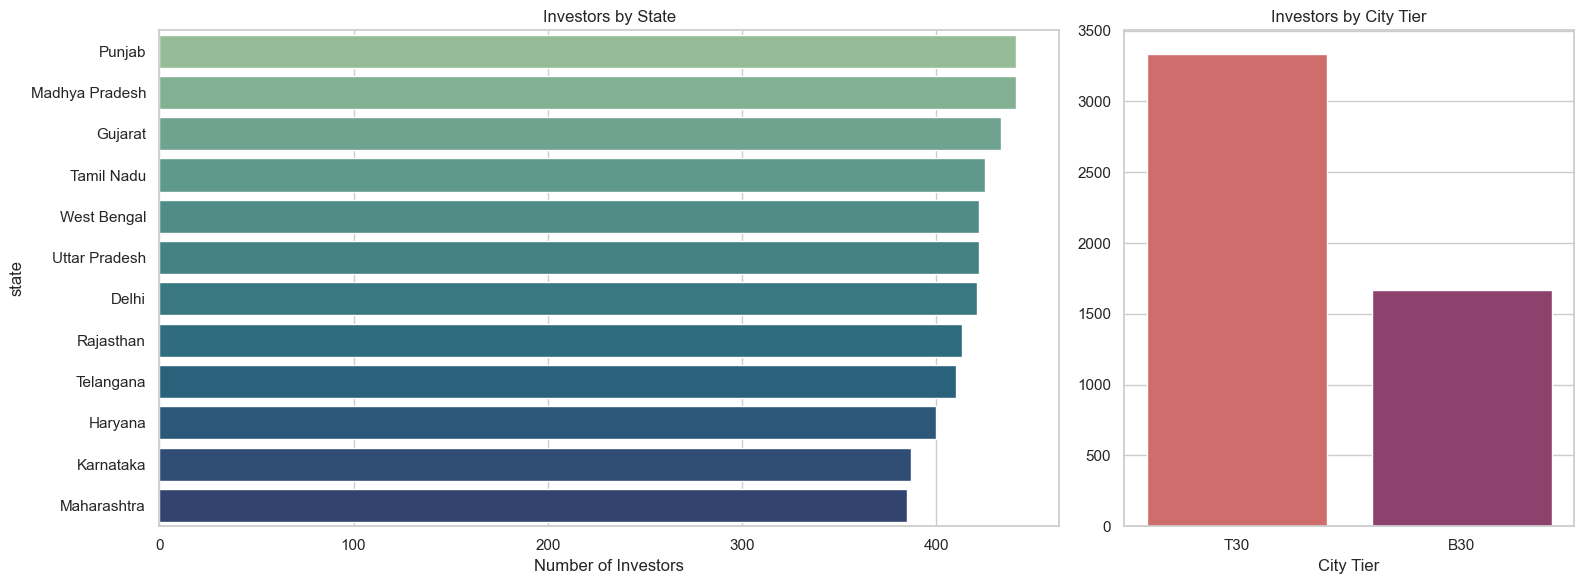

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})

sns.barplot(x=state_counts.values, y=state_counts.index, hue=state_counts.index,
            ax=axes[0], palette="crest", legend=False)
axes[0].set_title("Investors by State")
axes[0].set_xlabel("Number of Investors")

sns.barplot(x=tier_counts.index, y=tier_counts.values, hue=tier_counts.index,
            ax=axes[1], palette="flare", legend=False)
axes[1].set_title("Investors by City Tier")
axes[1].set_xlabel("City Tier")

plt.tight_layout()
plt.savefig(FIG_DIR / "06_geography.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding: State Distribution is Unusually Flat; City Tier Split is Realistic

State-level investor counts are unusually flat (~15% spread across all 11 states) — 
inconsistent with real-world Indian mutual fund geography, which is typically 
concentrated in financial hub states. City tier, however, shows a realistic and 
consistent T30/B30 split (~67%/33%) across both genders independently, suggesting 
this field was deliberately modeled on real urban-concentration patterns.

## SECTION 8: Chart 7 — Folio Count Growth

### Reshape for Plotting

In [57]:
folio_long = folio.melt(
    id_vars="month",
    value_vars=["equity_folios_crore", "debt_folios_crore", "hybrid_folios_crore", "others_folios_crore"],
    var_name="category", value_name="folios_crore"
)
folio_long["category"] = folio_long["category"].str.replace("_folios_crore", "").str.title()

### Plot

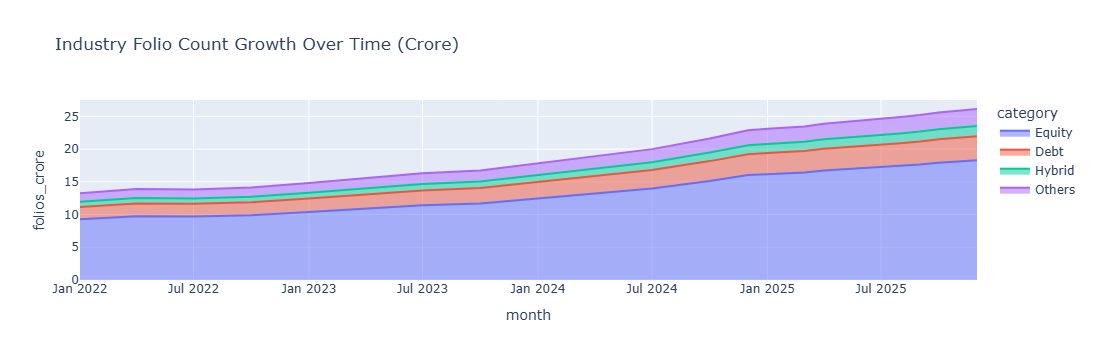

In [58]:
fig = px.area(
    folio_long, x="month", y="folios_crore", color="category",
    title="Industry Folio Count Growth Over Time (Crore)"
)
fig.show()
#fig.write_image(str(FIG_DIR / "07_folio_growth.png"), width=1200, height=700, scale=2)

### Finding: Folio Count Nearly Doubled, With Accelerating Growth

Industry-wide folio count nearly doubled from ~13.3 Cr (Jan 2022) to ~26 Cr (Jan 2026), 
with growth accelerating in 2024-2025. Equity folios remain dominant throughout, 
consistent with the Equity-heavy SIP inflow pattern (Finding 4).

## SECTION 9: Chart 8 — NAV Correlation Matrix (10 Funds)

### Add 4 More Funds

In [59]:
additional_codes = {
    "148569": "Mirae Asset Tax Saver (ELSS)",
    "102887": "UTI Flexi Cap (Flexi Cap)",
    "120506": "ICICI Pru Value Discovery (Value)",
    "118635": "Nippon India ETF Nifty 50 BeES (Index/ETF)",
}
ten_fund_codes = {**representative_codes, **additional_codes}

### Compute Correlation

In [60]:
nav_subset = fact_nav[fact_nav["amfi_code"].isin(ten_fund_codes.keys())]
nav_pivot = nav_subset.pivot(index="date", columns="amfi_code", values="nav")
nav_pivot.columns = [ten_fund_codes[c] for c in nav_pivot.columns]

nav_returns = nav_pivot.pct_change().dropna()
corr_matrix = nav_returns.corr()

### Plot

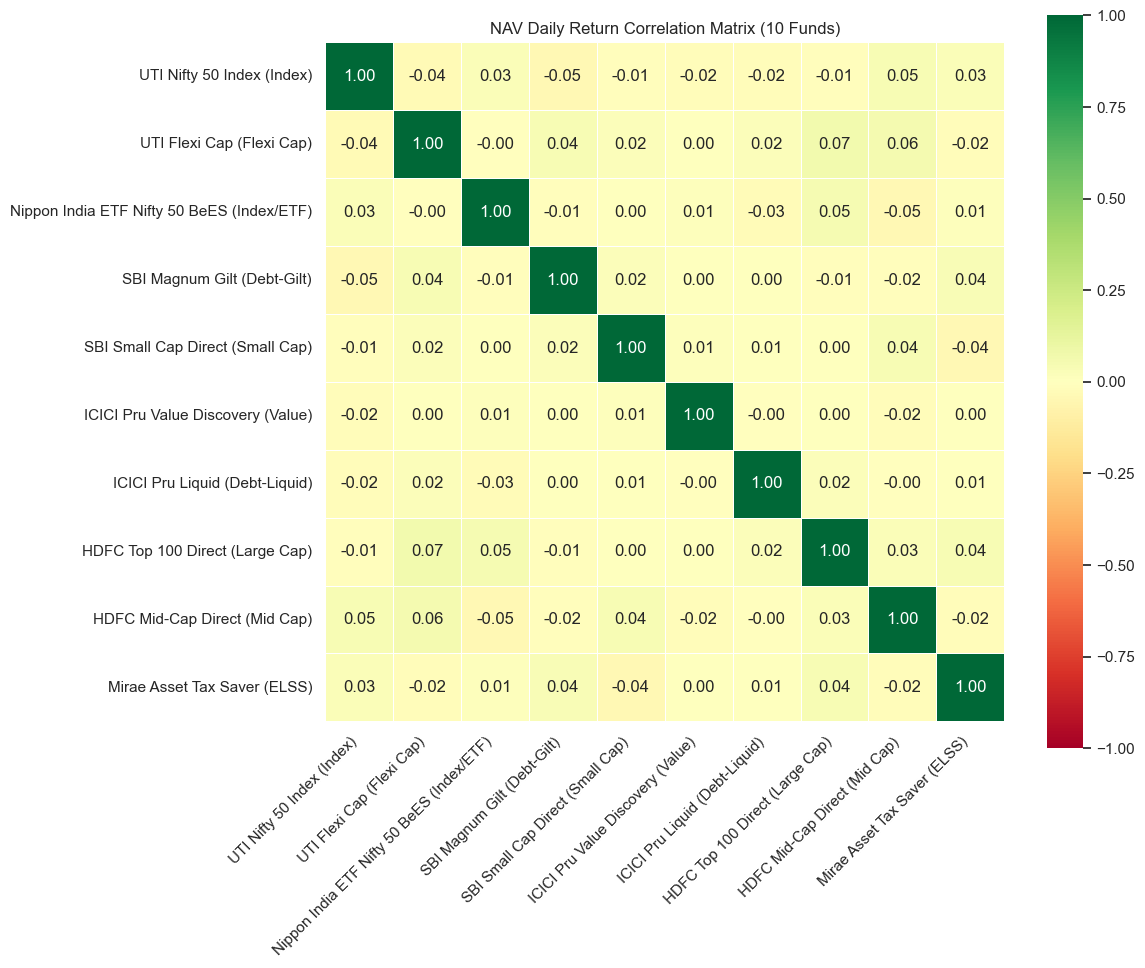

In [61]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("NAV Daily Return Correlation Matrix (10 Funds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding: NAV Series Show No Cross-Fund Correlation

Across 10 funds spanning 8 sub-categories, all pairwise NAV return correlations stay 
near zero (±0.07) — including between two funds tracking the *same* Nifty 50 index 
(UTI Nifty 50 Index vs. Nippon India ETF Nifty 50 BeES, r=0.03), which should be almost 
perfectly correlated in reality. This indicates NAV series were generated independently 
per fund, without a shared market factor.

## SECTION 10: Chart 9 — Sector Allocation Donut

### Filter to Equity Funds and Sum by Sector

In [62]:
holdings_with_cat = holdings.merge(dim_fund[["amfi_code", "category"]], on="amfi_code", how="left")
equity_holdings = holdings_with_cat[holdings_with_cat["category"] == "Equity"]

sector_allocation = equity_holdings.groupby("sector")["market_value_cr"].sum()
sector_allocation = sector_allocation.sort_values(ascending=False).reset_index()

### Plot

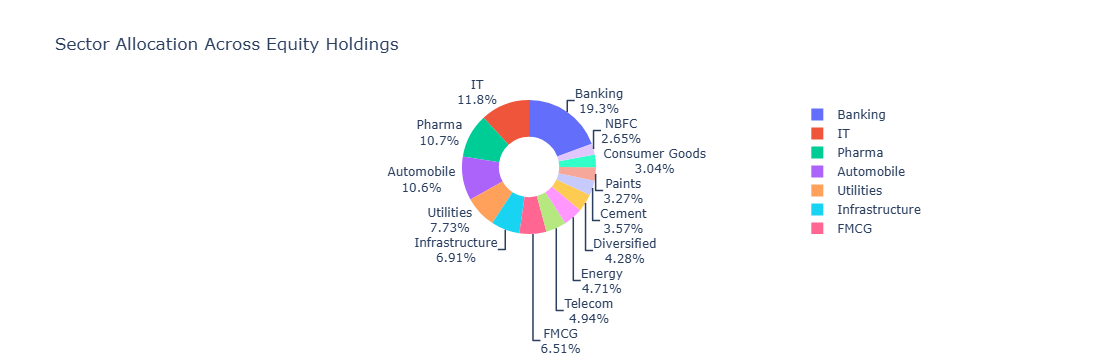

In [63]:
fig = px.pie(
    sector_allocation, names="sector", values="market_value_cr",
    title="Sector Allocation Across Equity Holdings", hole=0.45
)
fig.update_traces(textinfo="percent+label", textposition="outside")
fig.show()
#fig.write_image(str(FIG_DIR / "09_sector_donut.png"), width=900, height=700, scale=2)

### Finding: Banking Leads Sector Allocation

Stock-level sector allocation across Equity fund holdings shows Banking as the dominant 
sector (19.3%, ₹62,840 Cr), followed by IT (11.8%), Pharma (10.7%), and Automobile 
(10.6%) — a realistic mix that mirrors real Indian equity market sector weightings.

## SECTION 11: Chart 10 — Returns by Horizon and Category

### Prepare Data

In [64]:
perf = fact_performance.merge(
    dim_fund[["amfi_code", "scheme_name", "category"]],
    on="amfi_code", how="left"
)

returns_long = perf.melt(
    id_vars=["scheme_name", "category"],
    value_vars=["return_1yr_pct", "return_3yr_pct", "return_5yr_pct"],
    var_name="horizon", value_name="return_pct"
)
returns_long["horizon"] = returns_long["horizon"].str.replace("return_", "").str.replace("_pct", "").str.upper()

### Plot

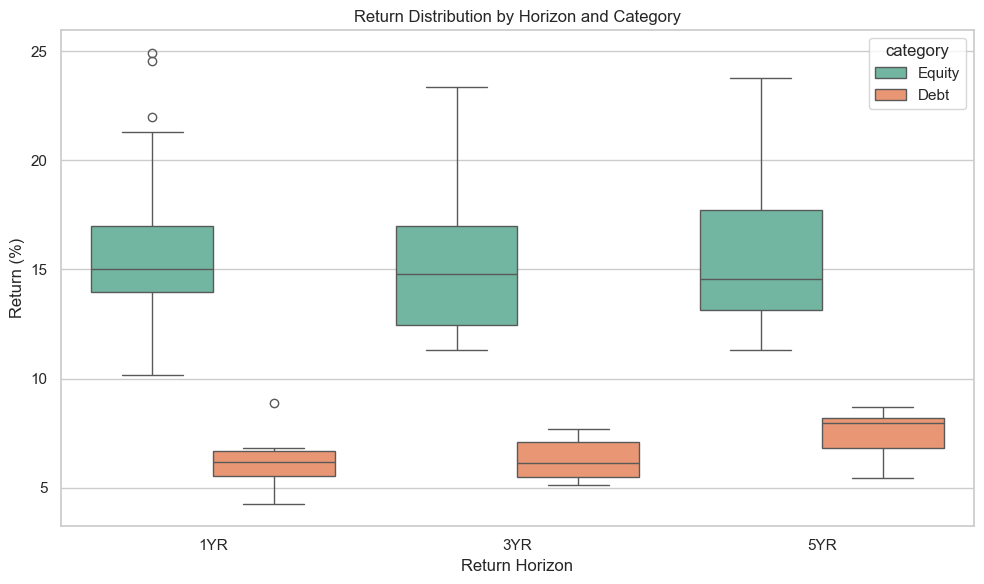

In [65]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=returns_long, x="horizon", y="return_pct", hue="category", palette="Set2")
plt.title("Return Distribution by Horizon and Category")
plt.xlabel("Return Horizon")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_returns_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## SECTION 12: Chart 11 — Risk-Return Scatter

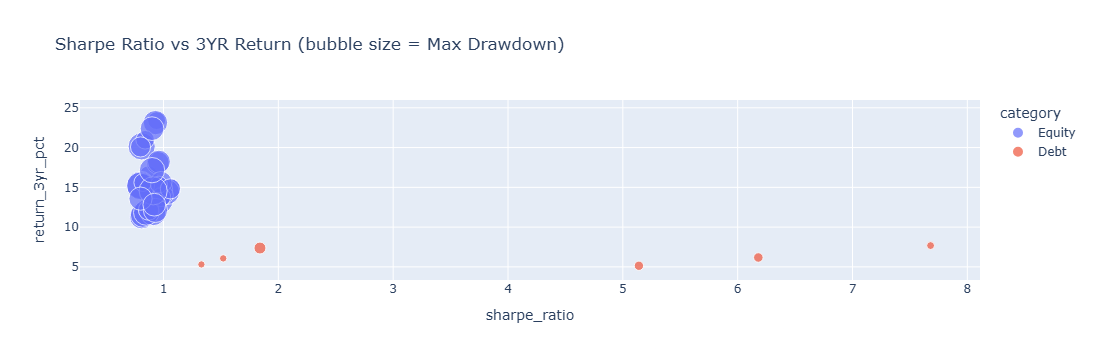

In [66]:
fig = px.scatter(
    perf, x="sharpe_ratio", y="return_3yr_pct", color="category",
    size=perf["max_drawdown_pct"].abs(),
    hover_name="scheme_name",
    title="Sharpe Ratio vs 3YR Return (bubble size = Max Drawdown)"
)
fig.show()
#fig.write_image(str(FIG_DIR / "11_risk_return_scatter.png"), width=1000, height=700, scale=2)

### Finding: Debt Fund Sharpe Ratios Are Unrealistically High

All 34 Equity funds show tightly-clustered, realistic Sharpe ratios (mean 0.91, range 
0.80-1.06), while all 6 Debt funds show unusually high and variable Sharpe ratios 
(mean 3.95, range 1.33-7.68). Real-world Sharpe ratios rarely exceed 2-3 — this 
indicates Debt fund volatility was modeled unrealistically low relative to its returns, 
a systematic pattern across the whole category.

## SECTION 13: Chart 12 — Alpha vs Beta

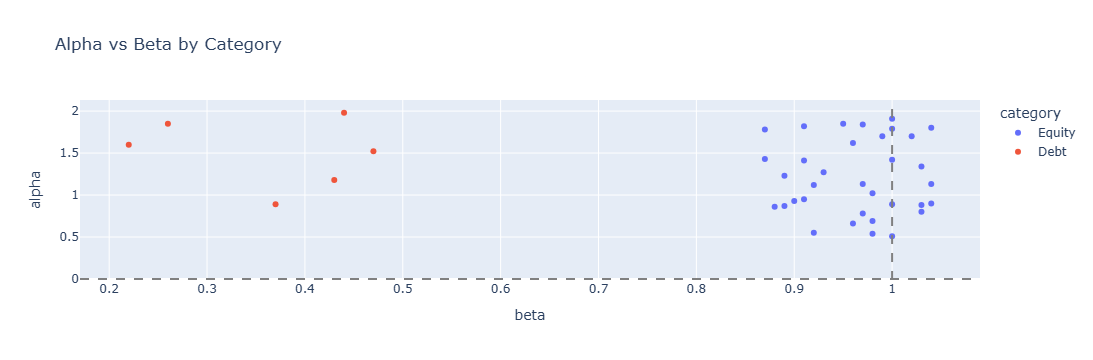

In [67]:
fig = px.scatter(
    perf, x="beta", y="alpha", color="category",
    hover_name="scheme_name",
    title="Alpha vs Beta by Category"
)
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.add_vline(x=1, line_dash="dash", line_color="gray")
fig.show()
#fig.write_image(str(FIG_DIR / "12_alpha_beta.png"), width=1000, height=700, scale=2)

## SECTION 14: Chart 13 — Age Group Pie Chart 

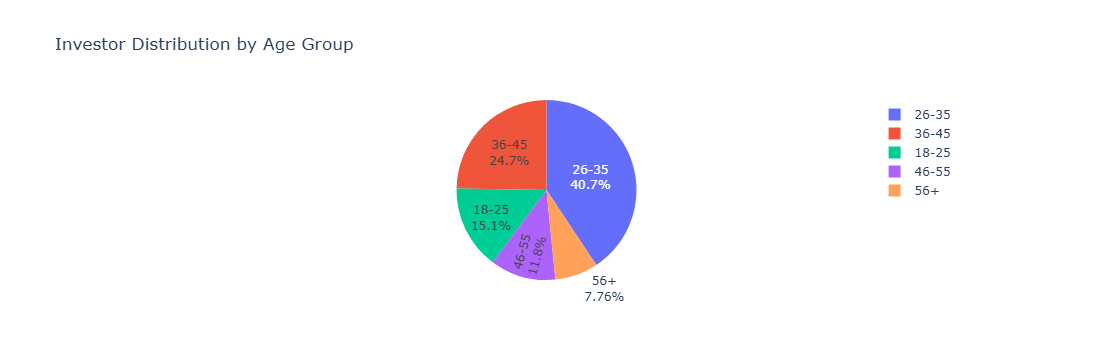

In [68]:
fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Distribution by Age Group",
    hole=0
)
fig.update_traces(textinfo="percent+label")
fig.show()
#fig.write_image(str(FIG_DIR / "13_age_pie.png"), width=800, height=700, scale=2)

## SECTION 15: Chart 14 — SIP Amount by Age Group 

### Prepare the Data

In [69]:
sip_transactions = fact_transactions[fact_transactions["transaction_type"] == "SIP"]

### Plot

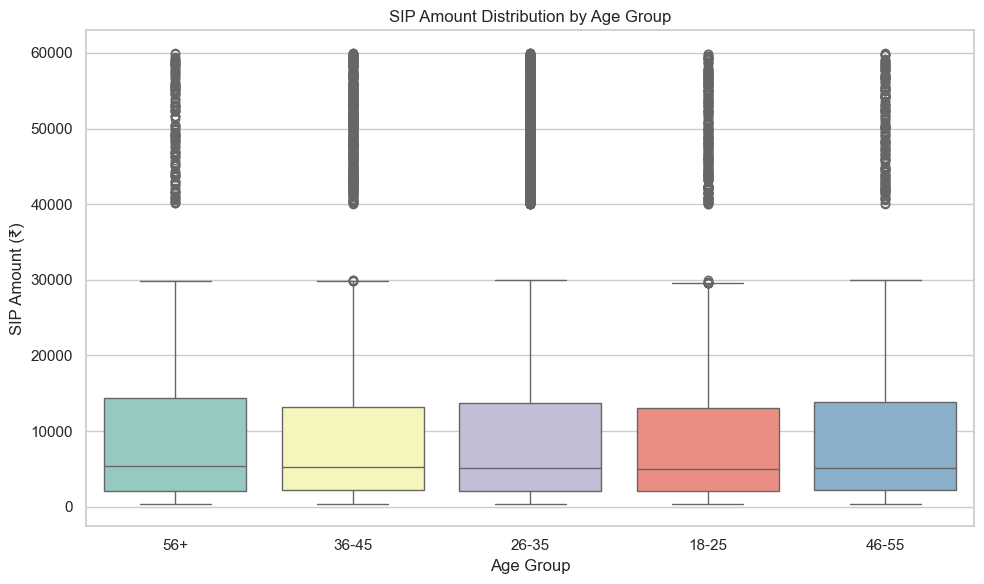

In [70]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_transactions, x="age_group", y="amount_inr", hue="age_group", palette="Set3", legend=False)
plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05b_sip_amount_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

### SECTION 16: Chart 15 — SIP Amount by State 

### Sum SIP Amount by State

In [71]:
state_sip_amount = sip_transactions.groupby("state")["amount_inr"].sum()
state_sip_amount = state_sip_amount.sort_values(ascending=False)

### Plot

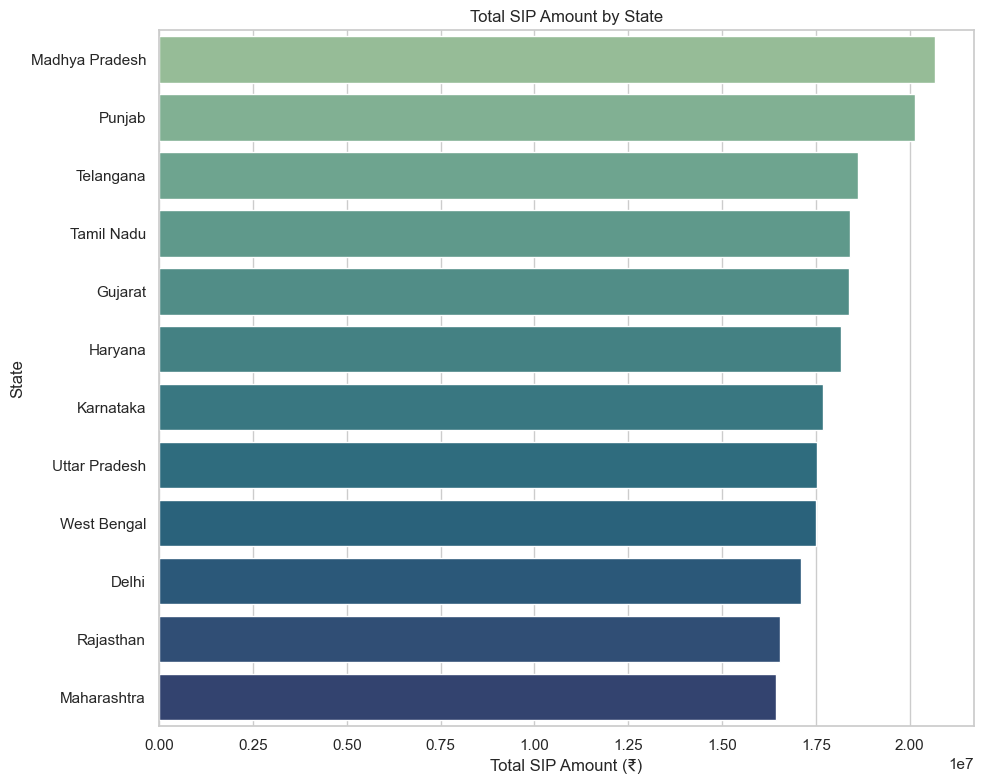

In [72]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x=state_sip_amount.values,
    y=state_sip_amount.index,
    hue=state_sip_amount.index,
    palette="crest",
    legend=False
)
plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(FIG_DIR / "06b_sip_amount_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

### SECTION 17: Chart 16 — T30/B30 Pie Chart

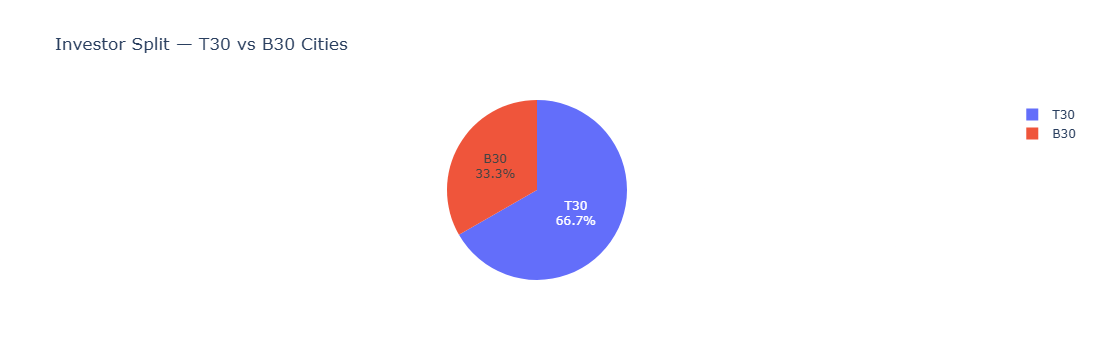

In [73]:
fig = px.pie(
    values=tier_counts.values,
    names=tier_counts.index,
    title="Investor Split — T30 vs B30 Cities",
    hole=0
)
fig.update_traces(textinfo="percent+label")
fig.show()
#fig.write_image(str(FIG_DIR / "16_tier_pie.png"), width=800, height=700, scale=2)